<a href="https://colab.research.google.com/github/Suyash-Codes-AI/RP/blob/master/RP_PAPER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numpy

In [2]:
!pip install boruta xgboost lightgbm scikit-learn pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 3.6 MB/s eta 0:00:00


In [3]:
import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from google.colab import files
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.feature_selection import RFECV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from boruta import BorutaPy
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

SEED=42
TEST_SIZE=8759
CV_FOLDS=5
JOBS=-1
RESULTS_DIR=Path('/content/results')
RESULTS_DIR.mkdir(exist_ok=True)

In [4]:
uploaded=files.upload()
if not uploaded: raise RuntimeError('No file uploaded.')
filename=next(iter(uploaded))
DATA=Path('/content')/filename
print('Uploaded:', DATA)


Saving Steel_industry_data (1).csv to Steel_industry_data (1).csv
Uploaded: /content/Steel_industry_data (1).csv


In [5]:
df=pd.read_csv(DATA)
print('Shape:',df.shape)
print('Columns:',df.columns.tolist())
print('\nMissing values:\n',df.isna().sum())
required=['date','Usage_kWh','Lagging_Current_Reactive.Power_kVarh','Leading_Current_Reactive_Power_kVarh','CO2(tCO2)','Lagging_Current_Power_Factor','Leading_Current_Power_Factor','NSM','WeekStatus','Day_of_week','Load_Type']
missing=[c for c in required if c not in df.columns]
if missing: raise ValueError(f'Missing columns: {missing}')
if df.isna().sum().sum(): raise ValueError('Dataset contains missing values.')


Shape: (35040, 11)
Columns: ['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type']

Missing values:
 date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64


In [6]:
df['Timestamp']=pd.to_datetime(df['date'],dayfirst=True,errors='raise')
df=df.sort_values('Timestamp').reset_index(drop=True)
calc_nsm=df.Timestamp.dt.hour*3600+df.Timestamp.dt.minute*60+df.Timestamp.dt.second
calc_week=np.where(df.Timestamp.dt.dayofweek>=5,'Weekend','Weekday')
print('NSM matches timestamp:',bool((calc_nsm==df.NSM).all()))
print('WeekStatus matches timestamp:',bool(np.array_equal(calc_week,df.WeekStatus)))
print('Day_of_week matches timestamp:',bool(np.array_equal(df.Timestamp.dt.day_name(),df.Day_of_week)))
df=df.rename(columns={'Usage_kWh':'Usage','Lagging_Current_Reactive.Power_kVarh':'LagRP','Leading_Current_Reactive_Power_kVarh':'LeadRP','CO2(tCO2)':'CO2','Lagging_Current_Power_Factor':'LagPF','Leading_Current_Power_Factor':'LeadPF'})


NSM matches timestamp: True
WeekStatus matches timestamp: True
Day_of_week matches timestamp: True


In [7]:
predictors=['LagRP','LeadRP','CO2','LagPF','LeadPF','NSM','WeekStatus','Day_of_week','Load_Type']
data=df[predictors+['Usage']].copy()
train_df,test_df=train_test_split(data,test_size=TEST_SIZE,random_state=SEED,shuffle=True)
y_train=train_df.Usage.to_numpy(); y_test=test_df.Usage.to_numpy()
print('Train:',len(train_df),'Test:',len(test_df))

numeric=['LagRP','LeadRP','CO2','LagPF','LeadPF','NSM']
categorical=['WeekStatus','Day_of_week','Load_Type']
enc=OneHotEncoder(handle_unknown='ignore',drop=None,sparse_output=False)
transformer=ColumnTransformer([('num','passthrough',numeric),('cat',enc,categorical)])
X_train=pd.DataFrame(transformer.fit_transform(train_df),columns=transformer.get_feature_names_out(),index=train_df.index)
X_test=pd.DataFrame(transformer.transform(test_df),columns=transformer.get_feature_names_out(),index=test_df.index)
print('Encoded predictors:',X_train.shape[1])


Train: 26281 Test: 8759
Encoded predictors: 18


In [9]:
from sklearn.ensemble import RandomForestRegressor

# Configure Boruta with a faster estimator (fewer trees and limited depth) to prevent timeouts
fast_rf = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=SEED, n_jobs=JOBS)
boruta = BorutaPy(fast_rf, n_estimators='auto', max_iter=50, perc=100, alpha=0.05, two_step=False, random_state=SEED, verbose=2)

print("Starting Boruta Feature Selection...")
boruta.fit(X_train.to_numpy(), y_train)

boruta_results = pd.DataFrame({
    'feature': X_train.columns,
    'confirmed': boruta.support_,
    'tentative': boruta.support_weak_,
    'rank': boruta.ranking_
})
boruta_results.to_csv(RESULTS_DIR / 'boruta_results_5models.csv', index=False)
boruta_features = boruta_results.loc[boruta_results.confirmed, 'feature'].tolist()

# Fallback to all features if none are confirmed
if len(boruta_features) == 0:
    boruta_features = X_train.columns.tolist()
    print("No features confirmed. Using all features as fallback.")

print('Confirmed features:', len(boruta_features))
print(boruta_features)

Starting Boruta Feature Selection...
Iteration: 	1 / 50
Confirmed: 	0
Tentative: 	18
Rejected: 	0
Iteration: 	2 / 50
Confirmed: 	0
Tentative: 	18
Rejected: 	0
Iteration: 	3 / 50
Confirmed: 	0
Tentative: 	18
Rejected: 	0
Iteration: 	4 / 50
Confirmed: 	0
Tentative: 	18
Rejected: 	0
Iteration: 	5 / 50
Confirmed: 	0
Tentative: 	18
Rejected: 	0
Iteration: 	6 / 50
Confirmed: 	0
Tentative: 	18
Rejected: 	0
Iteration: 	7 / 50
Confirmed: 	0
Tentative: 	18
Rejected: 	0
Iteration: 	8 / 50
Confirmed: 	0
Tentative: 	18
Rejected: 	0
Iteration: 	9 / 50
Confirmed: 	7
Tentative: 	0
Rejected: 	11


BorutaPy finished running.

Iteration: 	10 / 50
Confirmed: 	7
Tentative: 	0
Rejected: 	11
Confirmed features: 7
['num__LagRP', 'num__LeadRP', 'num__CO2', 'num__LagPF', 'num__LeadPF', 'num__NSM', 'cat__Load_Type_Light_Load']


In [10]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import KFold

X_boruta = X_train[boruta_features]
X_test_boruta = X_test[boruta_features]

cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

# Speed up RFE by using a faster decision tree or light forest
fast_rfe_rf = RandomForestRegressor(n_estimators=30, max_depth=6, random_state=SEED, n_jobs=JOBS)
rfecv = RFECV(fast_rfe_rf, step=1, min_features_to_select=1, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=JOBS)

print("Starting RFECV Feature Selection...")
rfecv.fit(X_boruta, y_train)

selected_features = X_boruta.columns[rfecv.support_].tolist()
pd.DataFrame({
    'feature': X_boruta.columns,
    'selected': rfecv.support_,
    'rank': rfecv.ranking_
}).to_csv(RESULTS_DIR / 'rfe_results_5models.csv', index=False)

X_final_train = X_boruta[selected_features]
X_final_test = X_test_boruta[selected_features]
print('RFE selected features:', len(selected_features))
print(selected_features)

Starting RFECV Feature Selection...
RFE selected features: 4
['num__LagRP', 'num__CO2', 'num__LagPF', 'num__LeadPF']


In [11]:
from sklearn.svm import SVR

def rmse(y, p):
    return float(np.sqrt(mean_squared_error(y, p)))

def mape(y, p):
    y = np.asarray(y)
    p = np.asarray(p)
    mask = (y != 0)
    return float(np.mean(np.abs((y[mask] - p[mask]) / y[mask])) * 100)

def cv_pct(y, p):
    return rmse(y, p) / np.mean(y) * 100

def evaluate(name, model):
    print(f"Training {name}...")
    t = time.perf_counter()
    model.fit(X_final_train, y_train)
    pred = model.predict(X_final_test)
    sec = time.perf_counter() - t
    row = {
        'Model': name,
        'RMSE': rmse(y_test, pred),
        'MAE': float(mean_absolute_error(y_test, pred)),
        'MAPE_percent': mape(y_test, pred),
        'CV_percent': cv_pct(y_test, pred),
        'Fit_seconds': sec
    }
    print(f"{name}: RMSE={row['RMSE']:.6f}, MAE={row['MAE']:.6f}, MAPE={row['MAPE_percent']:.4f}%, CV={row['CV_percent']:.4f}%, Time={row['Fit_seconds']:.2f}s")
    return row

results = []
results.append(evaluate('Linear Regression', LinearRegression()))
results.append(evaluate('KNN', Pipeline([('scaler', StandardScaler()), ('model', KNeighborsRegressor(n_neighbors=2, weights='distance', p=2, n_jobs=JOBS))])))
results.append(evaluate('Random Forest', RandomForestRegressor(n_estimators=100, max_depth=12, random_state=SEED, n_jobs=JOBS)))
results.append(evaluate('XGBoost', XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, objective='reg:squarederror', eval_metric='rmse', random_state=SEED, n_jobs=JOBS)))
results.append(evaluate('LightGBM', LGBMRegressor(n_estimators=200, learning_rate=0.05, num_leaves=31, max_depth=-1, subsample=0.8, colsample_bytree=0.8, objective='regression', random_state=SEED, n_jobs=JOBS, verbosity=-1)))
# Adding Support Vector Regression (SVR) inside a scaling pipeline
results.append(evaluate('SVM', Pipeline([('scaler', StandardScaler()), ('model', SVR(C=1.0, epsilon=0.1))])))

Training Linear Regression...
Linear Regression: RMSE=4.288847, MAE=2.615247, MAPE=19.1050%, CV=15.5995%, Time=0.03s
Training KNN...
KNN: RMSE=1.112822, MAE=0.489574, MAPE=5.5271%, CV=4.0476%, Time=0.07s
Training Random Forest...
Random Forest: RMSE=1.290124, MAE=0.641270, MAPE=6.2500%, CV=4.6925%, Time=3.27s
Training XGBoost...
XGBoost: RMSE=1.856009, MAE=1.123898, MAPE=7.9896%, CV=6.7507%, Time=1.81s
Training LightGBM...
LightGBM: RMSE=1.725039, MAE=1.040527, MAPE=8.1875%, CV=6.2743%, Time=0.64s
Training SVM...
SVM: RMSE=2.299289, MAE=1.120249, MAPE=7.8826%, CV=8.3630%, Time=30.60s


In [12]:
results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df.to_csv(RESULTS_DIR / 'seven_model_comparison_with_svm.csv', index=False)
print('=== FINAL MODEL COMPARISON (sorted by RMSE) ===')
display(results_df.round(6))

=== FINAL MODEL COMPARISON (sorted by RMSE) ===


,Model,RMSE,MAE,MAPE_percent,CV_percent,Fit_seconds
0,KNN,1.112822,0.489574,5.527060,4.047580,0.070713
1,Random Forest,1.290124,0.641270,6.250006,4.692467,3.268630
2,LightGBM,1.725039,1.040527,8.187508,6.274347,0.641722
3,XGBoost,1.856009,1.123898,7.989550,6.750714,1.806085
4,SVM,2.299289,1.120249,7.882640,8.363021,30.596024
5,Linear Regression,4.288847,2.615247,19.104956,15.599484,0.027185


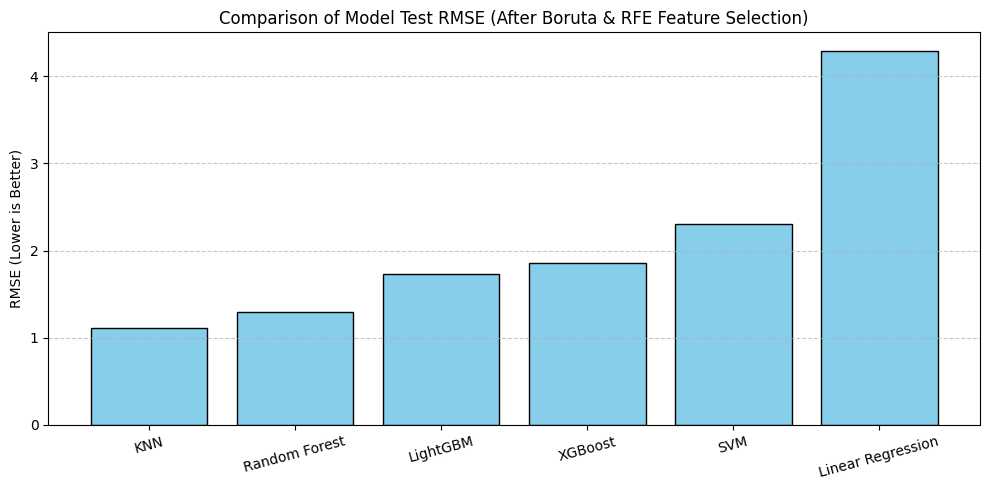

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.bar(results_df.Model, results_df.RMSE, color='skyblue', edgecolor='black')
plt.ylabel('RMSE (Lower is Better)')
plt.title('Comparison of Model Test RMSE (After Boruta & RFE Feature Selection)')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [14]:
results_df=pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df.to_csv(RESULTS_DIR/'five_model_comparison.csv',index=False)
pd.DataFrame({'feature':selected_features}).to_csv(RESULTS_DIR/'final_selected_features_5models.csv',index=False)
print('=== FINAL 5-MODEL COMPARISON ===')
display(results_df.round(6))
print('Best model:',results_df.iloc[0].Model)


=== FINAL 5-MODEL COMPARISON ===


,Model,RMSE,MAE,MAPE_percent,CV_percent,Fit_seconds
0,KNN,1.112822,0.489574,5.527060,4.047580,0.070713
1,Random Forest,1.290124,0.641270,6.250006,4.692467,3.268630
2,LightGBM,1.725039,1.040527,8.187508,6.274347,0.641722
3,XGBoost,1.856009,1.123898,7.989550,6.750714,1.806085
4,SVM,2.299289,1.120249,7.882640,8.363021,30.596024
5,Linear Regression,4.288847,2.615247,19.104956,15.599484,0.027185


Best model: KNN


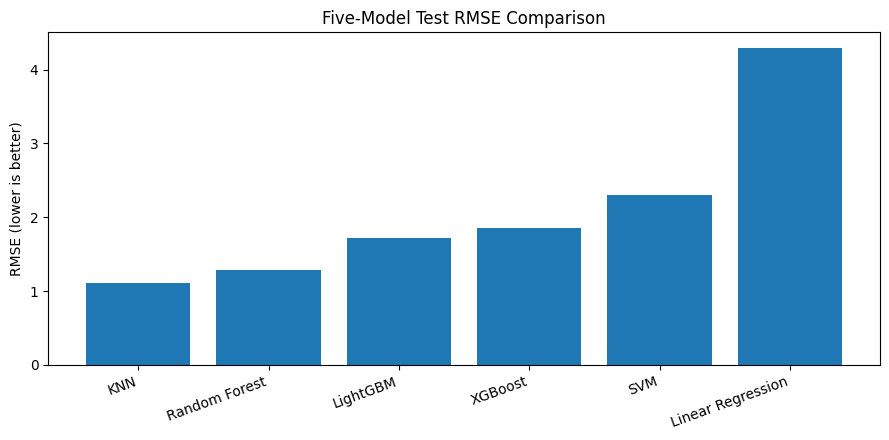

In [15]:
plt.figure(figsize=(9,4.5))
plt.bar(results_df.Model,results_df.RMSE)
plt.ylabel('RMSE (lower is better)')
plt.title('Five-Model Test RMSE Comparison')
plt.xticks(rotation=20,ha='right')
plt.tight_layout(); plt.show()


In [16]:
print('Result files:')
for f in sorted(RESULTS_DIR.iterdir()): print(f.name)
# Optional download:
# files.download(str(RESULTS_DIR/'five_model_comparison.csv'))


Result files:
boruta_results_5models.csv
final_selected_features_5models.csv
five_model_comparison.csv
rfe_results_5models.csv
seven_model_comparison_with_svm.csv
